In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import wandb

/opt/homebrew/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.4.1)/charset_normalizer (3.4.1) doesn't match a supported version!
  warnings.warn(


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # maps [0,1] -> [-1,1]
])

full_train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset_full = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

full_dataset = torch.utils.data.ConcatDataset([full_train_dataset, test_dataset_full])

total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 56000
Val: 7000
Test: 7000


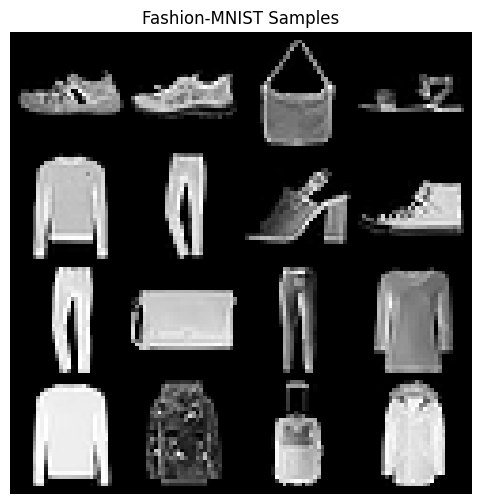

In [4]:
def denormalize(img):
    return img * 0.5 + 0.5

images, labels = next(iter(train_loader))
grid = make_grid(denormalize(images[:16]), nrow=4)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("Fashion-MNIST Samples")
plt.show()

In [5]:
def get_noise(batch_size, latent_dim, device):
    return torch.randn(batch_size, latent_dim, device=device)

In [6]:
class VanillaGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.model(z)
        return x.view(-1, 1, 28, 28)
    
class VanillaDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.model(x)

In [7]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.ReLU(True)
        )
        
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 7 -> 14
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 14 -> 28
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 128, 7, 7)
        x = self.deconv(x)
        return x

In [8]:
class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),   # 28 -> 14
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 14 -> 7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 1)
        )

    def forward(self, x):
        return self.model(x)

In [9]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1 or classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [10]:
bce_loss = nn.BCEWithLogitsLoss()
mse_loss = nn.MSELoss()

def discriminator_bce_loss(real_logits, fake_logits):
    real_labels = torch.ones_like(real_logits)
    fake_labels = torch.zeros_like(fake_logits)
    
    real_loss = bce_loss(real_logits, real_labels)
    fake_loss = bce_loss(fake_logits, fake_labels)
    return real_loss + fake_loss

def generator_bce_loss(fake_logits):
    real_labels = torch.ones_like(fake_logits)
    return bce_loss(fake_logits, real_labels)

def discriminator_lsgan_loss(real_logits, fake_logits):
    real_labels = torch.ones_like(real_logits)
    fake_labels = torch.zeros_like(fake_logits)
    
    real_loss = mse_loss(real_logits, real_labels)
    fake_loss = mse_loss(fake_logits, fake_labels)
    return real_loss + fake_loss

def generator_lsgan_loss(fake_logits):
    real_labels = torch.ones_like(fake_logits)
    return mse_loss(fake_logits, real_labels)

def discriminator_wgan_loss(real_logits, fake_logits):
    return -(torch.mean(real_logits) - torch.mean(fake_logits))

def generator_wgan_loss(fake_logits):
    return -torch.mean(fake_logits)

In [11]:
def get_optimizer(params, optimizer_name="adam", lr=2e-4):
    optimizer_name = optimizer_name.lower()
    
    if optimizer_name == "sgd":
        return optim.SGD(params, lr=lr, momentum=0.9)
    elif optimizer_name == "rmsprop":
        return optim.RMSprop(params, lr=lr)
    elif optimizer_name == "adam":
        return optim.Adam(params, lr=lr, betas=(0.5, 0.999))
    else:
        raise ValueError("optimizer_name must be 'sgd', 'rmsprop', or 'adam'")

In [12]:
def build_gan(model_type="vanilla", latent_dim=100):
    if model_type == "vanilla":
        G = VanillaGenerator(latent_dim=latent_dim).to(device)
        D = VanillaDiscriminator().to(device)
    elif model_type == "dcgan":
        G = DCGenerator(latent_dim=latent_dim).to(device)
        D = DCDiscriminator().to(device)
    else:
        raise ValueError("model_type must be 'vanilla' or 'dcgan'")
    
    G.apply(weights_init)
    D.apply(weights_init)
    
    return G, D

In [13]:
def train_gan(
    generator,
    discriminator,
    train_loader,
    g_optimizer,
    d_optimizer,
    latent_dim=100,
    epochs=10,
    loss_type="bce",
    model_type="vanilla",
    clip_value=0.01
):
    history = {
        "g_loss": [],
        "d_loss": []
    }
    
    fixed_noise = get_noise(16, latent_dim, device)
    generated_snapshots = []
    
    for epoch in range(epochs):
        generator.train()
        discriminator.train()
        
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0
        
        for real_images, _ in train_loader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)
            
            # -------------------------
            # Train Discriminator
            # -------------------------
            z = get_noise(batch_size, latent_dim, device)
            fake_images = generator(z).detach()
            
            d_optimizer.zero_grad()
            
            real_logits = discriminator(real_images)
            fake_logits = discriminator(fake_images)
            
            if loss_type == "bce":
                d_loss = discriminator_bce_loss(real_logits, fake_logits)
            elif loss_type == "lsgan":
                d_loss = discriminator_lsgan_loss(real_logits, fake_logits)
            elif loss_type == "wgan":
                d_loss = discriminator_wgan_loss(real_logits, fake_logits)
            else:
                raise ValueError("loss_type must be 'bce', 'lsgan', or 'wgan'")
            
            d_loss.backward()
            d_optimizer.step()
            
            if loss_type == "wgan":
                for p in discriminator.parameters():
                    p.data.clamp_(-clip_value, clip_value)
            
            # -------------------------
            # Train Generator
            # -------------------------
            z = get_noise(batch_size, latent_dim, device)
            g_optimizer.zero_grad()
            
            generated_images = generator(z)
            fake_logits = discriminator(generated_images)
            
            if loss_type == "bce":
                g_loss = generator_bce_loss(fake_logits)
            elif loss_type == "lsgan":
                g_loss = generator_lsgan_loss(fake_logits)
            elif loss_type == "wgan":
                g_loss = generator_wgan_loss(fake_logits)
            
            g_loss.backward()
            g_optimizer.step()
            
            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()
        
        avg_g_loss = epoch_g_loss / len(train_loader)
        avg_d_loss = epoch_d_loss / len(train_loader)
        
        history["g_loss"].append(avg_g_loss)
        history["d_loss"].append(avg_d_loss)
        
        # Save snapshot
        generator.eval()
        with torch.no_grad():
            fake_samples = generator(fixed_noise).cpu()
        generated_snapshots.append(fake_samples)
        
        print(f"Epoch [{epoch+1}/{epochs}] | G Loss: {avg_g_loss:.4f} | D Loss: {avg_d_loss:.4f}")
    
    return history, generated_snapshots

In [14]:
def plot_gan_history(history, title="GAN Training History"):
    plt.figure(figsize=(8, 5))
    plt.plot(history["g_loss"], label="Generator Loss")
    plt.plot(history["d_loss"], label="Discriminator Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def show_generated_images(images, title="Generated Images"):
    images = denormalize(images)
    grid = make_grid(images, nrow=4)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()

Epoch [1/10] | G Loss: 1.2583 | D Loss: 1.0495
Epoch [2/10] | G Loss: 1.3459 | D Loss: 1.1555
Epoch [3/10] | G Loss: 1.1680 | D Loss: 1.2415
Epoch [4/10] | G Loss: 1.0621 | D Loss: 1.2713
Epoch [5/10] | G Loss: 1.0806 | D Loss: 1.2765
Epoch [6/10] | G Loss: 1.0694 | D Loss: 1.2735
Epoch [7/10] | G Loss: 1.0408 | D Loss: 1.2749
Epoch [8/10] | G Loss: 1.0492 | D Loss: 1.2703
Epoch [9/10] | G Loss: 1.0353 | D Loss: 1.2849
Epoch [10/10] | G Loss: 0.9802 | D Loss: 1.3080


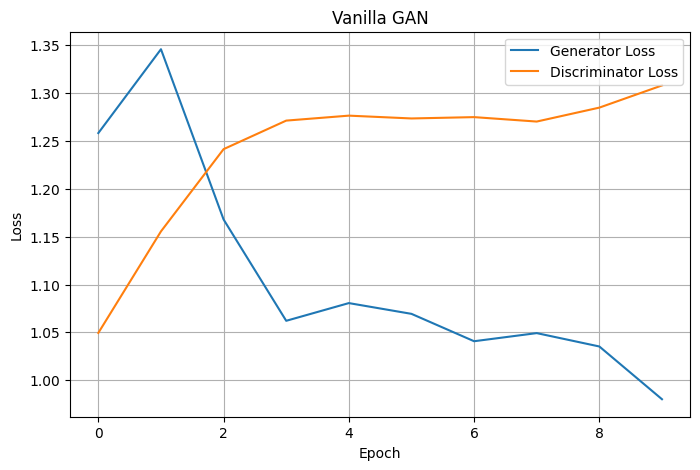

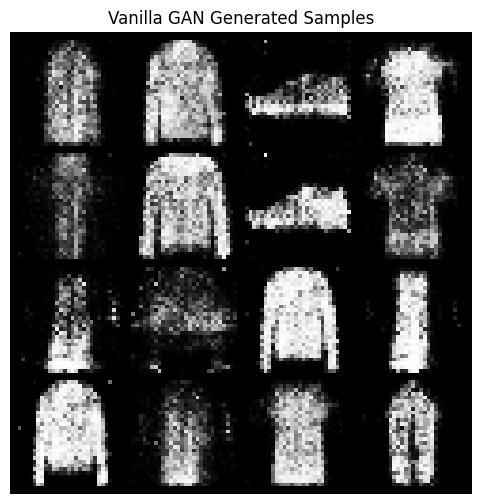

In [15]:
latent_dim = 100
model_type = "vanilla"
loss_type = "bce"
optimizer_name = "adam"
epochs = 10

G, D = build_gan(model_type=model_type, latent_dim=latent_dim)

g_optimizer = get_optimizer(G.parameters(), optimizer_name=optimizer_name, lr=2e-4)
d_optimizer = get_optimizer(D.parameters(), optimizer_name=optimizer_name, lr=2e-4)

history, snapshots = train_gan(
    generator=G,
    discriminator=D,
    train_loader=train_loader,
    g_optimizer=g_optimizer,
    d_optimizer=d_optimizer,
    latent_dim=latent_dim,
    epochs=epochs,
    loss_type=loss_type,
    model_type=model_type
)

plot_gan_history(history, title="Vanilla GAN")
show_generated_images(snapshots[-1], title="Vanilla GAN Generated Samples")

Epoch [1/10] | G Loss: 1.2536 | D Loss: 1.0439
Epoch [2/10] | G Loss: 1.4325 | D Loss: 1.1215
Epoch [3/10] | G Loss: 1.2204 | D Loss: 1.2226
Epoch [4/10] | G Loss: 1.0264 | D Loss: 1.2889
Epoch [5/10] | G Loss: 0.9560 | D Loss: 1.3090
Epoch [6/10] | G Loss: 1.0252 | D Loss: 1.2977
Epoch [7/10] | G Loss: 1.0318 | D Loss: 1.2819
Epoch [8/10] | G Loss: 1.0135 | D Loss: 1.2893
Epoch [9/10] | G Loss: 0.9758 | D Loss: 1.2998
Epoch [10/10] | G Loss: 0.9600 | D Loss: 1.3129


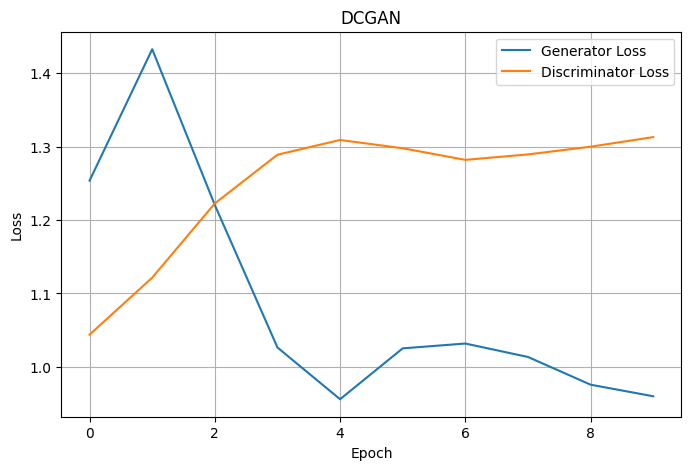

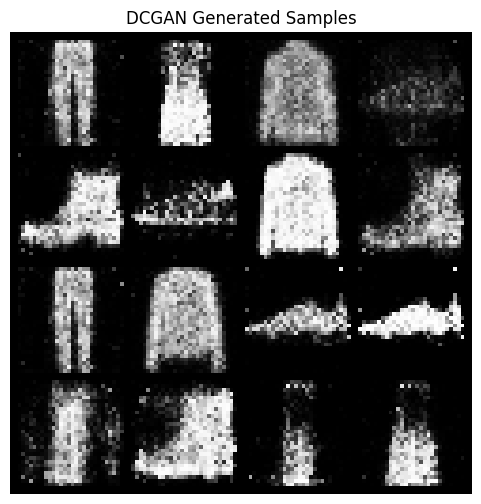

In [16]:
latent_dim = 100
l_type = "dcgan"
loss_type = "bce"
optimizer_name = "adam"
epochs = 10
    
G, D = build_gan(model_type=model_type, latent_dim=latent_dim)

g_optimizer = get_optimizer(G.parameters(), optimizer_name=optimizer_name, lr=2e-4)
d_optimizer = get_optimizer(D.parameters(), optimizer_name=optimizer_name, lr=2e-4)

history, snapshots = train_gan(
    generator=G,
    discriminator=D,
    train_loader=train_loader,
    g_optimizer=g_optimizer,
    d_optimizer=d_optimizer,
    latent_dim=latent_dim,
    epochs=epochs,
    loss_type=loss_type,
    model_type=model_type
)

plot_gan_history(history, title="DCGAN")
show_generated_images(snapshots[-1], title="DCGAN Generated Samples")

In [17]:
model_types = ["vanilla", "dcgan"]
loss_types = ["bce", "lsgan", "wgan"]
optimizer_names = ["sgd", "rmsprop", "adam"]

results = []

for model_type in model_types:
    for loss_type in loss_types:
        for optimizer_name in optimizer_names:
            print(f"\n=== {model_type.upper()} | {loss_type.upper()} | {optimizer_name.upper()} ===")
            
            G, D = build_gan(model_type=model_type, latent_dim=100)
            
            g_optimizer = get_optimizer(G.parameters(), optimizer_name=optimizer_name, lr=2e-4)
            d_optimizer = get_optimizer(D.parameters(), optimizer_name=optimizer_name, lr=2e-4)
            
            history, snapshots = train_gan(
                generator=G,
                discriminator=D,
                train_loader=train_loader,
                g_optimizer=g_optimizer,
                d_optimizer=d_optimizer,
                latent_dim=100,
                epochs=5,
                loss_type=loss_type,
                model_type=model_type
            )
            
            results.append({
                "model_type": model_type,
                "loss_type": loss_type,
                "optimizer": optimizer_name,
                "final_g_loss": history["g_loss"][-1],
                "final_d_loss": history["d_loss"][-1]
            })


=== VANILLA | BCE | SGD ===
Epoch [1/5] | G Loss: 0.6950 | D Loss: 0.9959
Epoch [2/5] | G Loss: 0.6690 | D Loss: 0.8824
Epoch [3/5] | G Loss: 0.6826 | D Loss: 1.0229
Epoch [4/5] | G Loss: 0.7603 | D Loss: 0.9870
Epoch [5/5] | G Loss: 0.9816 | D Loss: 0.7985

=== VANILLA | BCE | RMSPROP ===
Epoch [1/5] | G Loss: 0.7035 | D Loss: 1.3181
Epoch [2/5] | G Loss: 0.7776 | D Loss: 1.3246
Epoch [3/5] | G Loss: 0.7839 | D Loss: 1.3359
Epoch [4/5] | G Loss: 0.7834 | D Loss: 1.3427
Epoch [5/5] | G Loss: 0.7818 | D Loss: 1.3475

=== VANILLA | BCE | ADAM ===
Epoch [1/5] | G Loss: 1.2307 | D Loss: 1.0823
Epoch [2/5] | G Loss: 1.3268 | D Loss: 1.1679
Epoch [3/5] | G Loss: 1.1005 | D Loss: 1.2553
Epoch [4/5] | G Loss: 1.0307 | D Loss: 1.2801
Epoch [5/5] | G Loss: 1.0253 | D Loss: 1.2893

=== VANILLA | LSGAN | SGD ===
Epoch [1/5] | G Loss: 0.6535 | D Loss: 0.1241
Epoch [2/5] | G Loss: 0.5932 | D Loss: 0.0866
Epoch [3/5] | G Loss: 0.5619 | D Loss: 0.1215
Epoch [4/5] | G Loss: 0.5970 | D Loss: 0.1237
Epo

In [18]:
import pandas as pd

results_df = pd.DataFrame(results)
print(results_df)
results_df.to_csv("gan_experiment_results.csv", index=False)

   model_type loss_type optimizer  final_g_loss  final_d_loss
0     vanilla       bce       sgd      0.981578      0.798544
1     vanilla       bce   rmsprop      0.781755      1.347463
2     vanilla       bce      adam      1.025330      1.289289
3     vanilla     lsgan       sgd      0.722903      0.089582
4     vanilla     lsgan   rmsprop      0.332207      0.455436
5     vanilla     lsgan      adam      0.469261      0.421270
6     vanilla      wgan       sgd     -3.593339     -0.350621
7     vanilla      wgan   rmsprop     -0.351864     -0.041633
8     vanilla      wgan      adam     -0.073882     -0.067294
9       dcgan       bce       sgd      3.567253      0.172328
10      dcgan       bce   rmsprop      0.784527      1.344473
11      dcgan       bce      adam      0.931830      1.212353
12      dcgan     lsgan       sgd      0.904460      0.082752
13      dcgan     lsgan   rmsprop      0.298816      0.542259
14      dcgan     lsgan      adam      0.378795      0.441608
15      

In [19]:
torch.save(G.state_dict(), "generator_final.pth")
torch.save(D.state_dict(), "discriminator_final.pth")

In [20]:
from huggingface_hub import create_repo, upload_file

create_repo("dl-lab9-gan", private=False, exist_ok=True)

upload_file(
    path_or_fileobj="discriminator_final.pth",
    path_in_repo="discriminator_final.pth",
    repo_id="25afi01-anmolkumar/dl-lab9-gan"
)

upload_file(
    path_or_fileobj="generator_final.pth",
    path_in_repo="generator_final.pth",
    repo_id="25afi01-anmolkumar/dl-lab9-gan"
)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/25afi01-anmolkumar/dl-lab9-gan/commit/75b46280e8313fdff55339767ec3544867eedf63', commit_message='Upload generator_final.pth with huggingface_hub', commit_description='', oid='75b46280e8313fdff55339767ec3544867eedf63', pr_url=None, repo_url=RepoUrl('https://huggingface.co/25afi01-anmolkumar/dl-lab9-gan', endpoint='https://huggingface.co', repo_type='model', repo_id='25afi01-anmolkumar/dl-lab9-gan'), pr_revision=None, pr_num=None)

In [21]:
def train_gan_wandb(generator, discriminator, train_loader, g_optimizer, d_optimizer, config):
    wandb.init(entity="anmolkumar_dtu", project="fashion-mnist-gan", config=config)
    
    latent_dim = config["latent_dim"]
    epochs = config["epochs"]
    loss_type = config["loss_type"]
    clip_value = config.get("clip_value", 0.01)

    fixed_noise = torch.randn(16, latent_dim, device=device)

    for epoch in range(epochs):
        generator.train()
        discriminator.train()

        g_epoch_loss = 0.0
        d_epoch_loss = 0.0

        for real_images, _ in train_loader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            # -------------------------
            # Train Discriminator
            # -------------------------
            z = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(z).detach()

            d_optimizer.zero_grad()

            real_logits = discriminator(real_images)
            fake_logits = discriminator(fake_images)

            if loss_type == "bce":
                real_labels = torch.ones_like(real_logits)
                fake_labels = torch.zeros_like(fake_logits)

                d_real_loss = nn.BCEWithLogitsLoss()(real_logits, real_labels)
                d_fake_loss = nn.BCEWithLogitsLoss()(fake_logits, fake_labels)
                d_loss = d_real_loss + d_fake_loss

            elif loss_type == "lsgan":
                real_labels = torch.ones_like(real_logits)
                fake_labels = torch.zeros_like(fake_logits)

                d_real_loss = nn.MSELoss()(real_logits, real_labels)
                d_fake_loss = nn.MSELoss()(fake_logits, fake_labels)
                d_loss = d_real_loss + d_fake_loss

            elif loss_type == "wgan":
                d_loss = -(torch.mean(real_logits) - torch.mean(fake_logits))

            d_loss.backward()
            d_optimizer.step()

            if loss_type == "wgan":
                for p in discriminator.parameters():
                    p.data.clamp_(-clip_value, clip_value)

            # -------------------------
            # Train Generator
            # -------------------------
            z = torch.randn(batch_size, latent_dim, device=device)

            g_optimizer.zero_grad()
            generated_images = generator(z)
            fake_logits = discriminator(generated_images)

            if loss_type == "bce":
                real_labels = torch.ones_like(fake_logits)
                g_loss = nn.BCEWithLogitsLoss()(fake_logits, real_labels)

            elif loss_type == "lsgan":
                real_labels = torch.ones_like(fake_logits)
                g_loss = nn.MSELoss()(fake_logits, real_labels)

            elif loss_type == "wgan":
                g_loss = -torch.mean(fake_logits)

            g_loss.backward()
            g_optimizer.step()

            g_epoch_loss += g_loss.item()
            d_epoch_loss += d_loss.item()

        g_epoch_loss /= len(train_loader)
        d_epoch_loss /= len(train_loader)

        wandb.log({
            "epoch": epoch + 1,
            "generator_loss": g_epoch_loss,
            "discriminator_loss": d_epoch_loss,
            "g_lr": g_optimizer.param_groups[0]["lr"],
            "d_lr": d_optimizer.param_groups[0]["lr"]
        })

        if epoch % 2 == 0:
            generator.eval()
            with torch.no_grad():
                sample_images = generator(fixed_noise).cpu()

            # convert from [-1,1] to [0,1]
            sample_images = (sample_images + 1) / 2.0

            wandb.log({
                "generated_samples": [
                    wandb.Image(sample_images[i].squeeze().numpy())
                    for i in range(min(4, sample_images.size(0)))
                ]
            })

        print(f"Epoch {epoch+1}: G_loss={g_epoch_loss:.4f}, D_loss={d_epoch_loss:.4f}")

    wandb.finish()

In [22]:
def build_gan_models(model_type="vanilla", latent_dim=100):
    if model_type == "vanilla":
        generator = VanillaGenerator(latent_dim=latent_dim).to(device)
        discriminator = VanillaDiscriminator().to(device)
    elif model_type == "dcgan":
        generator = DCGenerator(latent_dim=latent_dim).to(device)
        discriminator = DCDiscriminator().to(device)
    else:
        raise ValueError("model_type must be 'vanilla' or 'dcgan'")
    
    return generator, discriminator

def get_gan_optimizer(model, optimizer_name="adam", lr=2e-4):
    if optimizer_name == "sgd":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "rmsprop":
        return optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name == "adam":
        return optim.Adam(model.parameters(), lr=lr, betas=(0.5, 0.999))
    else:
        raise ValueError("optimizer_name must be 'sgd', 'rmsprop', or 'adam'")
    
model_types = ["vanilla", "dcgan"]
loss_types = ["bce", "lsgan", "wgan"]
optimizers_list = ["sgd", "rmsprop", "adam"]

for model_type in model_types:
    for loss_type in loss_types:
        for opt_name in optimizers_list:
            generator, discriminator = build_gan_models(
                model_type=model_type,
                latent_dim=100
            )

            g_optimizer = get_gan_optimizer(generator, optimizer_name=opt_name, lr=2e-4)
            d_optimizer = get_gan_optimizer(discriminator, optimizer_name=opt_name, lr=2e-4)

            config = {
                "model": model_type.upper(),
                "latent_dim": 100,
                "loss_type": loss_type,
                "optimizer": opt_name,
                "epochs": 5,
                "lr": 2e-4,
                "clip_value": 0.01
            }

            train_gan_wandb(
                generator=generator,
                discriminator=discriminator,
                train_loader=train_loader,
                g_optimizer=g_optimizer,
                d_optimizer=d_optimizer,
                config=config
            )


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/mckyzcky/.netrc.
wandb: Currently logged in as: anmolkumar_25afi01 (anmolkumar_dtu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1: G_loss=0.7987, D_loss=0.7792
Epoch 2: G_loss=0.7330, D_loss=0.8615
Epoch 3: G_loss=0.7711, D_loss=0.9623
Epoch 4: G_loss=0.9043, D_loss=0.9141
Epoch 5: G_loss=1.3630, D_loss=0.5817


d_lr,▁▁▁▁▁
discriminator_loss,▅▆█▇▁
epoch,▁▃▅▆█
g_lr,▁▁▁▁▁
generator_loss,▂▁▁▃█
d_lr,0.0002
discriminator_loss,0.58167
epoch,5
g_lr,0.0002
generator_loss,1.36301


Epoch 1: G_loss=0.7889, D_loss=1.2369
Epoch 2: G_loss=0.8501, D_loss=1.2628
Epoch 3: G_loss=0.8629, D_loss=1.2756
Epoch 4: G_loss=0.8692, D_loss=1.2754
Epoch 5: G_loss=0.8633, D_loss=1.2834


d_lr,▁▁▁▁▁
discriminator_loss,▁▅▇▇█
epoch,▁▃▅▆█
g_lr,▁▁▁▁▁
generator_loss,▁▆▇█▇
d_lr,0.0002
discriminator_loss,1.28337
epoch,5
g_lr,0.0002
generator_loss,0.86326


...

d_lr,▁▁▁▁▁
discriminator_loss,█▄▃▂▁
epoch,▁▃▅▆█
g_lr,▁▁▁▁▁
generator_loss,█▄▁▂▅
d_lr,0.0002
discriminator_loss,-0.06865
epoch,5
g_lr,0.0002
generator_loss,-0.00186


Epoch 1: G_loss=-0.0076, D_loss=-0.0013
Epoch 2: G_loss=-0.0075, D_loss=-0.0041
Epoch 3: G_loss=-0.0036, D_loss=-0.0031
Epoch 4: G_loss=-0.0032, D_loss=-0.0022
Epoch 5: G_loss=-0.0044, D_loss=-0.0017


d_lr,▁▁▁▁▁
discriminator_loss,█▁▃▆▇
epoch,▁▃▅▆█
g_lr,▁▁▁▁▁
generator_loss,▁▁▇█▆
d_lr,0.0002
discriminator_loss,-0.00174
epoch,5
g_lr,0.0002
generator_loss,-0.00435


Epoch 1: G_loss=-0.0021, D_loss=0.0003
Epoch 2: G_loss=-0.0024, D_loss=-0.0025
Epoch 3: G_loss=-0.0032, D_loss=-0.0037
Epoch 4: G_loss=-0.0030, D_loss=-0.0021
Epoch 5: G_loss=-0.0024, D_loss=-0.0021


d_lr,▁▁▁▁▁
discriminator_loss,█▃▁▄▄
epoch,▁▃▅▆█
g_lr,▁▁▁▁▁
generator_loss,█▆▁▂▆
d_lr,0.0002
discriminator_loss,-0.00205
epoch,5
g_lr,0.0002
generator_loss,-0.00237
